In [ ]:
"""
Data Mining Assignment
Author: Can Küçükyılmaz
Date: February 17, 2026
Description: Linear regression analysis of cholesterol levels and 
             classification modeling for home birth prediction.
"""

In [1]:
# Libraries

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
# Configuration

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Helper functions

def get_null_percentage(df):
    """Calculates the percentage of null values per column."""
    return df.isnull().mean().to_frame(name='percent_null') * 100

def load_data(filename, folder="raw"):
    """Robust data loader constructs OS-agnostic paths."""
    base_path = os.path.join(os.getcwd(), "data", folder, filename)
    if filename.endswith('.sav'):
        return pd.read_spss(base_path)
    elif filename.endswith('.csv'):
        return pd.read_csv(base_path)
    else:
        raise ValueError("Unsupported file format.")
    
def plot_residuals(model_fit, df, title='Distribution of Model Residuals'):
    """Plots histogram of residuals to check normality assumption."""
    residuals = model_fit.resid
    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=20, edgecolor='black', color='skyblue', density=True)
    sns.kdeplot(residuals, color='red', label='KDE')
    plt.title(title)
    plt.xlabel(r'Residuals ($Y - \hat{Y}$)')
    plt.ylabel('Density')
    plt.axvline(0, color='black', linestyle='--', label='Zero Error')
    plt.legend()
    plt.show()

In [4]:
# Cholesterol Analysis (Linear Regression)

def analyze_simple_cholesterol(df):
    """
    Model 1: Univariate Linear Regression (Cholesterol ~ Age).
    """
    print("\n--- Model 1: Simple Regression (Age only) ---")
    
    sns.lmplot(x='leeftijd', y='chol', data=df, height=6, aspect=1.5)
    plt.title("Univariate: Cholesterol vs Age")
    plt.show()

    model = smf.ols('chol ~ leeftijd', data=df)
    results = model.fit()
    print(results.summary())
    return results

def analyze_multivariate_cholesterol(df):
    """
    Model 2: Multivariate Regression (Adjusted for BMI, Sex, Alcohol).
    """
    print("\n--- Model 2: Multivariate Regression (Adjusted) ---")
    
    # C() wrapper treats variables as categorical
    formula = 'chol ~ leeftijd + bmi + C(sekse) + C(alcohol)'
    model = smf.ols(formula, data=df)
    results = model.fit()
    print(results.summary())

    plot_residuals(results, df, title='Multivariate Model Residuals')
    return results

def run_cholesterol_study():
    print("--- Starting Cholesterol Study ---")
    try:
        chol_df = load_data("voorbeeld7_1.sav")
        analyze_simple_cholesterol(chol_df)
        analyze_multivariate_cholesterol(chol_df)
    except Exception as e:
        print(f"Skipping Cholesterol analysis: {e}")

In [5]:
# Birth Analysis

def preprocess_births(df):
    """Encapsulates cleaning logic for the births dataset."""
    df_clean = df.copy()
    
    # Target Engineering
    target_value = 'first line child birth, at home'
    df_clean['home'] = df_clean['child_birth'].apply(
        lambda x: 'at_home' if x == target_value else 'not_at_home'
    )
    
    # Feature Engineering
    df_clean["pari"] = df_clean["parity"].apply(lambda x: "primi" if x == 1 else "multi")
    df_clean['etni'] = df_clean['etnicity'].apply(lambda x: 'Dutch' if x == "Dutch" else 'Not Dutch')
    
    return df_clean

def analyze_births():
    print("\n--- Starting Births Analysis ---")
    try:
        births_df = load_data("births.csv")
    except Exception as e:
        print(f"Skipping Births analysis: {e}")
        return

    births_processed = preprocess_births(births_df)
    
    # Logical Order for Ordinal Variable
    age_order = [['< 25 year', '25-29 year', '30-34 year', '> 35 year']]
    
    X = births_processed[['pari', 'age_cat', 'etni', 'urban']]
    y = births_processed['home']

    # Pipeline A: Logistic Regression (Linear)
    logreg_pipeline = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('ord', OrdinalEncoder(categories=age_order), ['age_cat']),
            ('nom', OneHotEncoder(drop='first'), ['pari', 'etni', 'urban']) 
        ])),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    # Pipeline B: Decision Tree (Non-linear)
    tree_pipeline = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('ord', OrdinalEncoder(categories=age_order), ['age_cat']),
            ('nom', OneHotEncoder(drop=None), ['pari', 'etni', 'urban'])
        ])),
        ('classifier', DecisionTreeClassifier(random_state=42, max_depth=3))
    ])

    # Cross-Validation (10-fold)
    print("Running 10-Fold Cross-Validation...")
    scores_log = cross_val_score(logreg_pipeline, X, y, cv=10, scoring='accuracy')
    scores_tree = cross_val_score(tree_pipeline, X, y, cv=10, scoring='accuracy')

    print(f"Logistic Regression Accuracy: {scores_log.mean():.4f} (±{scores_log.std()*2:.4f})")
    print(f"Decision Tree Accuracy:       {scores_tree.mean():.4f} (±{scores_tree.std()*2:.4f})")

    # Visualization of Single Tree
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    tree_pipeline.fit(X_train, y_train)
    
    plt.figure(figsize=(20, 10), dpi=300)
    feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()
    plot_tree(tree_pipeline.named_steps['classifier'],
              feature_names=feature_names,
              class_names=list(tree_pipeline.named_steps['classifier'].classes_),
              filled=True, rounded=True, fontsize=10)
    plt.title("Decision Tree: Probability of Home Birth")
    plt.show()

--- Starting Cholesterol Study ---

--- Model 1: Simple Regression (Age only) ---


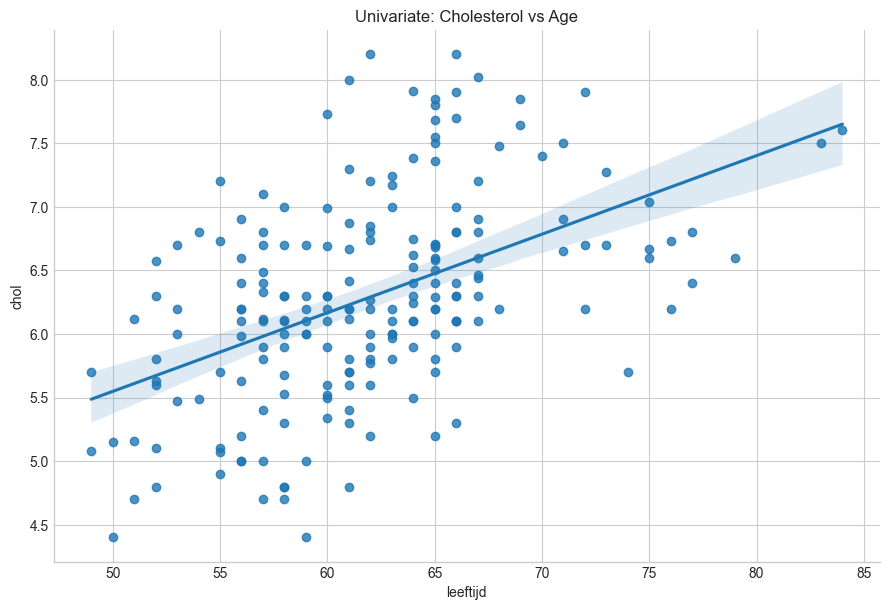

                            OLS Regression Results                            
Dep. Variable:                   chol   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     61.19
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           3.04e-13
Time:                        16:45:48   Log-Likelihood:                -212.39
No. Observations:                 200   AIC:                             428.8
Df Residuals:                     198   BIC:                             435.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4584      0.492      5.002      0.0

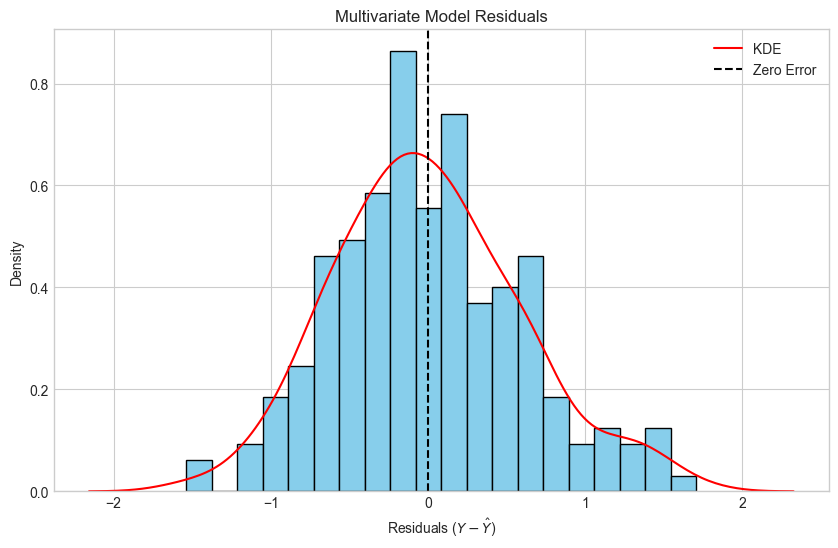


--- Starting Births Analysis ---
Running 10-Fold Cross-Validation...
Logistic Regression Accuracy: 0.6560 (±0.0060)
Decision Tree Accuracy:       0.6560 (±0.0060)


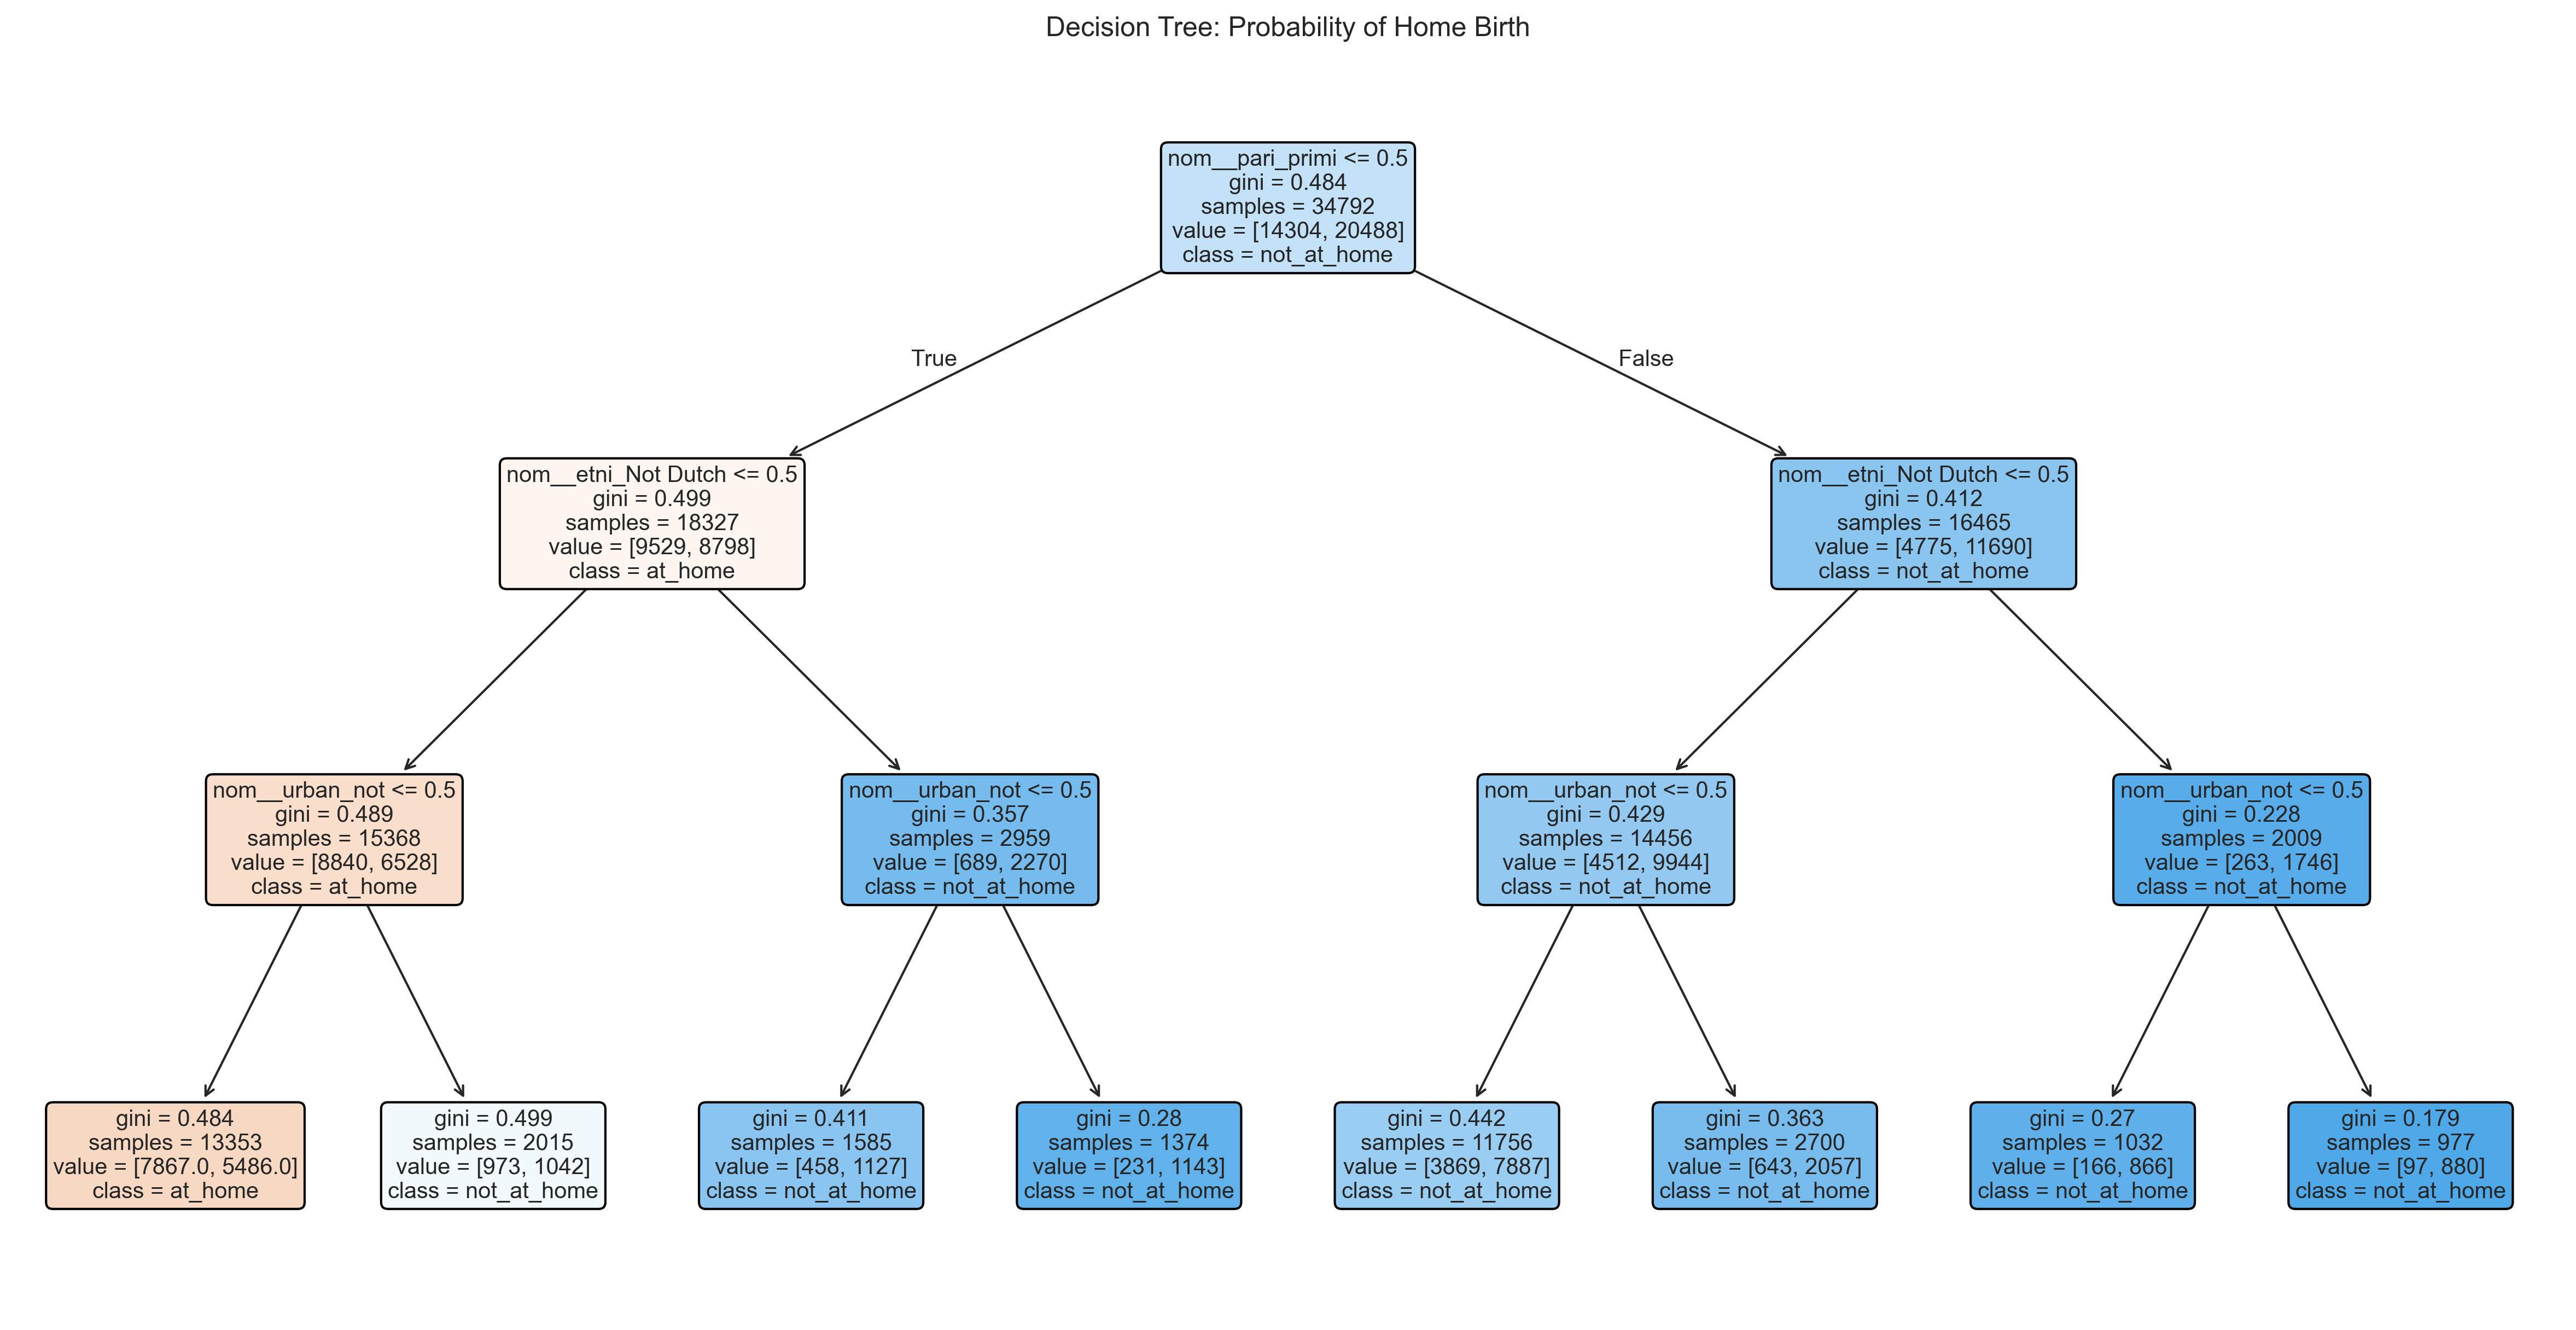

In [6]:
if __name__ == "__main__":
    run_cholesterol_study()
    analyze_births()

In [ ]:
# Answer to questions

